# BCSD Pipeline Demo

This notebook demonstrates the BCSD downscaling pipeline. It covers:

- Pydantic-based configuration (`BCSDConfig` + `PipelineOptions`)
- Automatic caching with S3 (via `ArtifactCache`)
- Three-stage architecture: observations → historical → scenario
- Environment-based isolation (`qa` / `production`)
- **Ensemble member lineage resolution** for G6 / SAI scenarios

We run a South Africa regional downscaling for CESM2-WACCM / `tas` / SSP245 and
visualise the results, then show how to configure a G6-1.5K run with correct lineage.


In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.orchestration import BCSDOrchestrator
from srm.pipeline import BCSDPipeline

## 1. Define Configuration

we'll configure a BCSD run for:
- GCM: CESM2-WACCM
- Variable: tas (temperature)
- Scenario: SSP245
- Region: South Africa
- Environment: qa (for testing)

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.96), np.float64(-20.15), np.float64(14.45), np.float64(39.89)]


In [3]:
# Operational settings (storage paths, environment, runtime flags).
# These live in PipelineOptions and do not affect the computation or cache key.
options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/cache",
    output_dir="s3://carbonplan-scratch/srm/output",
    branch="v0.10.0",
    environment="qa",
    verbose=True,
)

# Run-identity configuration (affects computation and is hashed for cache invalidation).
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="001",  # NCAR-format label used in the SSP245 store
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
)

print(f"Run ID:      {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Branch:      {options.branch}")
print(f"Detrend:     {config.variable_config.detrend_data}")

Run ID:      CESM2-WACCM_tas_001_SSP245_subset
Config hash: 14c38d635454
Branch:      v0.10.0
Detrend:     True


## 1b. Ensemble Member Lineage (G6 / SAI scenarios)

For SSP245 and other CMIP6-standard scenarios the `ensemble_member` label in
`BCSDConfig` maps directly to the coordinate label in the store, so no special
handling is needed.

For **G6 and other SAI scenarios** this breaks down: the G6 ensemble member
label (e.g. `"001"`) does not match the label used in the historical store
(`"r1i1p1f1"`) or the SSP245 bridge store. `srm.lineage.resolve_member_lineage`
encodes the correct mapping for every `(gcm, scenario, member, variable)` combination.

**Lineage is resolved automatically**: `BCSDPipeline.__init__` calls
`resolve_member_lineage` and stores the result on the pipeline instance:

| Attribute | Meaning |
|---|---|
| `pipeline._hist_member` | Member label used when loading historical GCM data |
| `pipeline._ssp245_member` | Member label used for the SSP245 bridge run (SAI only) |

You never need to set these manually. The pipeline logs `"Lineage resolved — ..."` at
init time whenever the resolved members differ from `ensemble_member`.


In [4]:
from srm.cli import _print_lineage_summary
from srm.lineage import resolve_member_lineage

# Direct lookup — useful when you need to inspect the mapping before running.
# resolve_member_lineage returns (historical, ssp245_bridge, ssp245_esgf); we
# ignore the ESGF-gap member here.
hist, ssp245, _ = resolve_member_lineage("CESM2-WACCM", "G6-1.5K", "001", "tas")
print(f"G6 001/tas    → historical={hist!r:12s}  ssp245_bridge={ssp245!r}")

# tasmax/tasmin use a corrected NCAR-provided historical run labelled "001".
hist_tmx, ssp245_tmx, _ = resolve_member_lineage("CESM2-WACCM", "G6-1.5K", "001", "tasmax")
print(f"G6 001/tasmax → historical={hist_tmx!r:12s}  ssp245_bridge={ssp245_tmx!r}")

# --- BCSDPipeline resolves lineage automatically at __init__ time ---
# Just pass the raw config and options; _hist_member and _ssp245_member are
# populated on the pipeline before any data is touched.

g6_config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="001",
    scenario="G6-1.5K",
    predict_period_start=2015,
    predict_period_end=2084,
    subset_bounds=tuple(bounds),
)
g6_pipeline = BCSDPipeline(g6_config, options)  # logs: "Lineage resolved — ..."

print("\nAfter BCSDPipeline init:")
print(f"  ensemble_member:  {g6_pipeline.config.ensemble_member}")
print(f"  _hist_member:     {g6_pipeline._hist_member}")
print(f"  _ssp245_member:   {g6_pipeline._ssp245_member}")

# --- Batch preview: inspect lineage for all G6 members before submitting ---
# _print_lineage_summary prints a rich table of resolved members for a list of configs.

g6_configs = [
    BCSDConfig(
        gcm="CESM2-WACCM",
        variable=var,
        ensemble_member=member,
        scenario="G6-1.5K",
        predict_period_start=2015,
        predict_period_end=2084,
    )
    for member in ("001", "002", "003")
    for var in ("tas", "pr", "rsds", "tasmax")
]
_print_lineage_summary(g6_configs)

G6 001/tas    → historical='r1i1p1f1'    ssp245_bridge='001'
G6 001/tasmax → historical='001'         ssp245_bridge='009'


[19:37:49] INFO     Lineage resolved — ensemble_member='001'  historical='r1i1p1f1'


After BCSDPipeline init:
  ensemble_member:  001
  _hist_member:     r1i1p1f1
  _ssp245_member:   001


                      Ensemble Member Lineage                       
                                                                    
  GCM           Variable   Member   → Historical   → SSP245 Bridge  
 ────────────────────────────────────────────────────────────────── 
  CESM2-WACCM   tas           001       r1i1p1f1                 —  
  CESM2-WACCM   pr            001       r1i1p1f1                 —  
  CESM2-WACCM   rsds          001       r1i1p1f1                 —  
  CESM2-WACCM   tasmax        001            001               009  
  CESM2-WACCM   tas           002       r2i1p1f1                 —  
  CESM2-WACCM   pr            002       r2i1p1f1                 —  
  CESM2-WACCM   rsds          002       r2i1p1f1                 —  
  CESM2-WACCM   tasmax        002            001               007  
  CESM2-WACCM   tas           003       r3i1p1f1                 —  
  CESM2-WACCM   pr            003       r3i1p1f1                 —  
  CESM2-WACCM   rsds          003       r3i1p1f1                 —  
  CESM2-WACCM   tasmax        003            001               008 

## 2. Run Pipeline

we can run the pipeline either:
- **Locally**: `use_coiled=False` - good for testing small regions
- **Coiled**: `use_coiled=True` - for large-scale runs

for this demo, we'll run locally since it's a small region.

In [5]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path}")

           INFO     Lineage resolved — ensemble_member='001'  historical='r1i1p1f1'  ssp245_bridge=None

Stage 1: Prepare observations (regrid ERA5 to GCM grid)


           INFO     Computing observation regridding for CESM2-WACCM/tas

[19:37:50] INFO     Loaded observations (0.96s)

[19:37:51] INFO     Regridded observations to coarse grid (1.07s)

...

           INFO     Re-trended scenario (0.01s)

[19:40:57] INFO     ✓ Saved debiased coarse scenario:                                                              
                    s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-48.96to-20.15_lon14.45to39.89.icechu
                    nk/debiased_coarse/ssp245/tas/001 (0.89s)

[19:41:37] INFO     Spatially disaggregated (39.35s)

[19:41:40] INFO     ✓ Saved scenario output:                                                                       
                    s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-48.96to-20.15_lon14.45to39.89.icechu
                    nk/ssp245/tas/001 (3.22s)

✓ Scenario output at: s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-48.96to-20.15_lon14.45to39.89.icechunk


In [6]:
# Alternatively, run all three stages in one call:
# scenario_path = BCSDPipeline(config, options).run_full_pipeline()
#
# This is equivalent to calling prepare_observations → fit_historical →
# transform_scenario in sequence and returns the path to the final output artifact.


In [7]:
# Load results by opening each cached artifact as a zarr group from its icechunk
# store, on the run's branch. This is the same access pattern documented in
# access-data.md: one store per (gcm, obs, subset), each artifact a zarr group.
def open_artifact(loc):
    """Open a cache StoreLocation (obs / historical / scenario) as an xr.Dataset."""
    return pipeline._open_from_icechunk(loc)

## 3. Load Results from Cache

the pipeline automatically caches intermediate artifacts and final outputs. let's load them for visualization.

In [8]:
# The final scenario output (fine-resolution, downscaled) lives in the
# `{scenario_group}/{variable}/{member}` group of the run's output store.
open_artifact(pipeline.cache.scenario_loc)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 31046, lat: 115, lon: 102)
Coordinates:
  * time     (time) datetime64[ns] 248kB 2015-01-01 2015-01-02 ... 2099-12-31
  * lat      (lat) float32 460B -48.75 -48.5 -48.25 ... -20.75 -20.5 -20.25
  * lon      (lon) float32 408B 14.5 14.75 15.0 15.25 ... 39.0 39.25 39.5 39.75
Data variables:
    tas      (time, lat, lon) float32 1GB dask.array<chunksize=(24000, 24, 48), meta=np.ndarray>
Attributes: (12/17)
    Conventions:                                 CF-1.8
    institution:                                 CarbonPlan
    history:                                     2026-07-20T19:41:37Z: BCSD d...
    srm_downscaling:version:                     0.10.0.post5+gf65d05f19.d202...
    srm_downscaling:gcm:                         CESM2-WACCM
    srm_downscaling:scenario:                    SSP245
    ...                                          ...
    srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
    srm_downscaling:downscaling_method:          additive
    srm_downscaling:train_period:                1978-2014
    srm_downscaling:config_hash:                 14c38d635454
    srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
    srm_downscaling:creation_date:               2026-07-20

In [9]:
# Load cached artifacts by opening their zarr groups. Lineage was already resolved
# on the pipeline (pipeline._hist_member) at init time.
obs_coarse = open_artifact(pipeline.cache.obs_loc)[config.variable]
historical_downscaled = open_artifact(pipeline.cache.historical_loc(pipeline._hist_member))[
    config.variable
]
scenario_downscaled = open_artifact(pipeline.cache.scenario_loc)[config.variable]

print("Observations (coarse):", obs_coarse)
print("Historical downscaled:", historical_downscaled)
print("Scenario downscaled:", scenario_downscaled)

Observations (coarse): <xarray.DataArray 'tas' (time: 23741, lat: 31, lon: 20)> Size: 59MB
dask.array<open_dataset-tas, shape=(23741, 31, 20), dtype=float32, chunksize=(23741, 31, 20), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01 1950-01-02 ... 2014-12-31
  * lat      (lat) float64 248B -48.53 -47.59 -46.65 ... -22.15 -21.2 -20.26
  * lon      (lon) float64 160B 15.0 16.25 17.5 18.75 ... 35.0 36.25 37.5 38.75
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K
Historical downscaled: <xarray.DataArray 'tas' (time: 13514, lat: 115, lon: 102)> Size: 634MB
dask.array<open_dataset-tas, shape=(13514, 115, 102), dtype=float32, chunksize=(13514, 32, 64), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
  * lat      (lat) float32 460B -48.75 -48.5 -48.25 ... -20.75 -20.5 -20.25
  * lon      (lon) float32 408B 14.5 14.75 15.0 15.25 ... 39.0 39.25 39

In [10]:
# Also load the raw GCM data for comparison
from srm.downscaling_utils import get_experiment, get_obs, subset_space
from srm.lineage import resolve_member_lineage

# Resolve lineage — for SAI/G6 scenarios the historical member differs from
# the scenario member label; falls back to config.ensemble_member if not registered.
hist_member = config.ensemble_member
try:
    hist_member, *_ = resolve_member_lineage(
        config.gcm, config.scenario, config.ensemble_member, config.variable
    )
except KeyError:
    pass

# Load fine-resolution observations
obs_fine = get_obs(var=config.variable)
obs_fine = subset_space(obs_fine, bounds)
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

# Load coarse GCM data using lineage-resolved historical member
model_hist_raw = get_experiment(gcm=config.gcm, scenario="historical", var=config.variable)
if "ensemble_member" in model_hist_raw.dims:
    model_hist_raw = model_hist_raw.sel(ensemble_member=hist_member)
model_hist_raw = subset_space(model_hist_raw, bounds)
model_hist_raw = model_hist_raw.sel(time=slice("1978", "2014"))

model_scenario_raw = get_experiment(gcm=config.gcm, scenario=config.scenario, var=config.variable)
model_scenario_raw = model_scenario_raw.sel(ensemble_member=config.ensemble_member)
model_scenario_raw = subset_space(model_scenario_raw, bounds)
model_scenario_raw = model_scenario_raw.sel(time=slice("2015", "2100"))

print("Loaded raw GCM data for comparison")

Loaded raw GCM data for comparison


## 4. Visualize Results at Cape Town

extract time series at Cape Town and compare:
1. raw model output (coarse)
2. debiased model output (coarse)
3. debiased + downscaled output (fine resolution)

In [11]:
# Get Cape Town coordinates
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_lon = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item())
cape_town_lat = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item())

print(f"Cape Town: ({cape_town_lat:.2f}°, {cape_town_lon:.2f}°)")

Cape Town: (-33.92°, 18.43°)


In [12]:
# Extract Cape Town data
obs_fine_ct = obs_fine.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()
obs_coarse_ct = obs_coarse.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()

model_hist_raw_ct = model_hist_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct = historical_downscaled.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

model_scenario_raw_ct = model_scenario_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct = scenario_downscaled.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

print("✓ Extracted Cape Town time series")

✓ Extracted Cape Town time series


### Distribution Comparison: Raw → Debiased → Downscaled

this shows how BCSD transforms the model output:
- **Left**: Raw GCM output (biased, coarse)
- **Middle**: after bias correction (matches obs distribution, coarse)
- **Right**: after bias correction + spatial disaggregation (fine resolution)

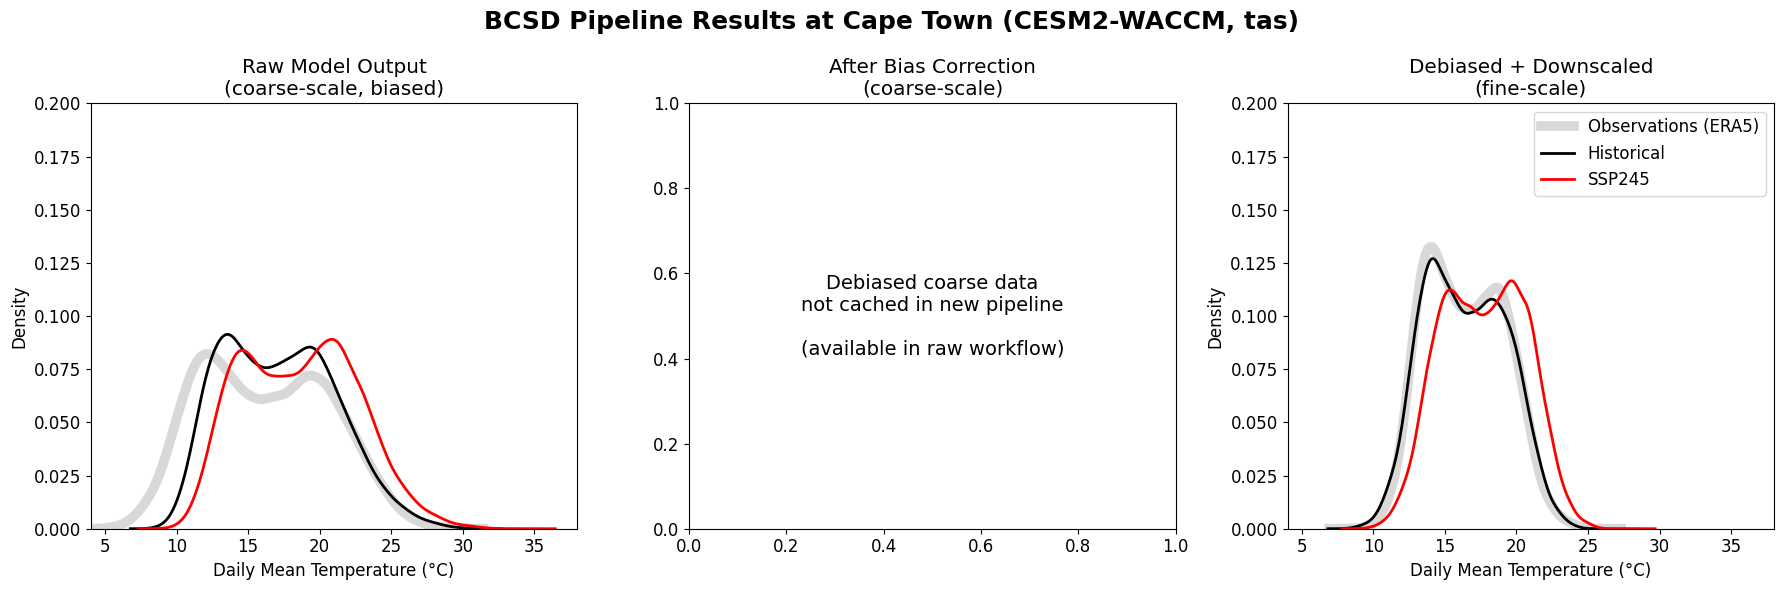

In [13]:
# Note: For the debiased coarse data, we need to compute it since pipeline doesn't cache it
# In production, we might want to cache the intermediate debiased-but-not-downscaled data

# Create figure
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["black", "red"]
labels = ["Historical", "SSP245"]


def format_subplot(ax, res="coarse"):
    """Add observation distribution to subplot"""
    if res == "coarse":
        sns.kdeplot(
            obs_coarse_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    elif res == "fine":
        sns.kdeplot(
            obs_fine_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    ax.set_ylim([0, 0.2])
    ax.set_xlim([4, 38])
    ax.set_xlabel("Daily Mean Temperature (°C)")


# Panel 1: Raw model output
ax = axes[0]
format_subplot(ax, res="coarse")
sns.kdeplot(
    model_hist_raw_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    model_scenario_raw_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Raw Model Output\n(coarse-scale, biased)")

# Panel 2: Note - we don't have direct access to debiased-but-not-downscaled
# This would require modifying the pipeline to cache that intermediate step
# For now, we'll skip this panel or note it as unavailable
ax = axes[1]
ax.text(
    0.5,
    0.5,
    "Debiased coarse data\nnot cached in new pipeline\n\n(available in raw workflow)",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=14,
)
ax.set_title("After Bias Correction\n(coarse-scale)")

# Panel 3: Downscaled output
ax = axes[2]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Debiased + Downscaled\n(fine-scale)")

plt.suptitle(
    f"BCSD Pipeline Results at Cape Town ({config.gcm}, {config.variable})",
    fontsize=18,
    fontweight="bold",
)

axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

### Time Series Comparison

let's also look at the annual mean temperature trends:

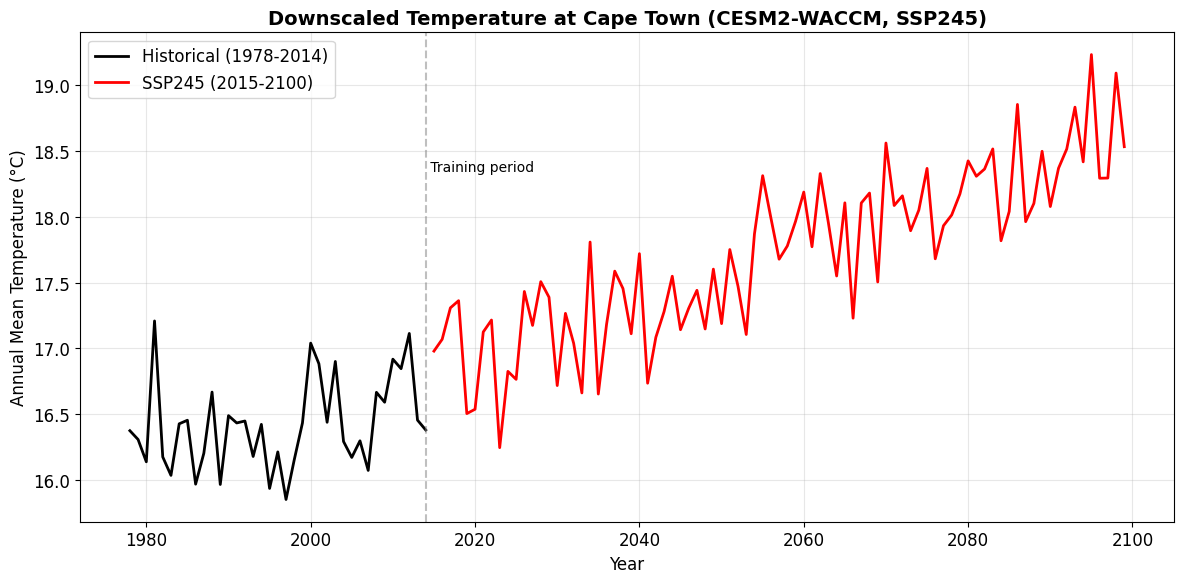

Historical mean: 16.42°C
2090s mean: 18.56°C
Warming: 2.14°C


In [14]:
# Compute annual means
hist_annual = historical_downscaled_ct.groupby("time.year").mean()
scenario_annual = scenario_downscaled_ct.groupby("time.year").mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hist_annual.year,
    hist_annual - 273.15,
    color="black",
    linewidth=2,
    label="Historical (1978-2014)",
)
ax.plot(
    scenario_annual.year,
    scenario_annual - 273.15,
    color="red",
    linewidth=2,
    label="SSP245 (2015-2100)",
)

ax.axvline(2014, color="gray", linestyle="--", alpha=0.5)
ax.text(2014, ax.get_ylim()[1] * 0.95, " Training period", fontsize=10, va="top")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Mean Temperature (°C)", fontsize=12)
ax.set_title(
    f"Downscaled Temperature at Cape Town ({config.gcm}, {config.scenario})",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Historical mean: {(hist_annual.mean() - 273.15).values:.2f}°C")
print(f"2090s mean: {(scenario_annual.sel(year=slice(2090, 2100)).mean() - 273.15).values:.2f}°C")
print(
    f"Warming: {(scenario_annual.sel(year=slice(2090, 2100)).mean() - hist_annual.mean()).values:.2f}°C"
)

## 5. Check Cache Status

the new pipeline automatically manages caching. let's inspect what's cached:

In [15]:
# Create orchestrator to check status
orchestrator = BCSDOrchestrator(options)
status = orchestrator.get_status([config])

print("Cache Status:")
print("=" * 60)
for stage, info in status.items():
    cached = info["cached"]
    total = info["total"]
    pct = (cached / total * 100) if total > 0 else 0
    print(f"{stage:25s}: {cached}/{total} ({pct:.0f}%) cached")
    if info["missing"]:
        print(f"  Missing: {', '.join(info['missing'])}")

Cache Status:
prepare_observations     : 1/1 (100%) cached
fit_historical           : 1/1 (100%) cached
transform_scenario       : 1/1 (100%) cached


## Next steps

### Running via the CLI (recommended)

The CLI handles lineage resolution, member validation, and dispatch automatically:

```bash
# QA smoke-test (South Africa subset, 4 vars × 3 members)
uv run bcsd run --config-path configs/qa/cesm2-waccm/cesm2-waccm-g6-southafrica.yaml

# Production global run
uv run bcsd run --config-path configs/production/cesm2-waccm/cesm2-waccm-g6.yaml

# Batch: run every config in a directory. A single config can be a matrix config
# whose list values (variables, members, scenarios) expand into all combinations.
uv run bcsd run --config-path configs/production/cesm2-waccm/
```

The `bcsd run` command prints an ensemble member lineage table before starting,
so you can verify the historical / SSP245 bridge assignments at a glance.

### Running via Python

Use `configs_from_matrix` (from `srm.cli`) to build configs for a multi-run batch,
then pass them to `BCSDOrchestrator`. `BCSDPipeline.__init__` logs the resolved
lineage for each config it processes.

```python
from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.cli import configs_from_matrix
from srm.orchestration import BCSDOrchestrator

configs, options = configs_from_matrix(
    gcms=["CESM2-WACCM"],
    variables=["tas", "pr", "rsds", "tasmax"],
    members=["001", "002", "003"],
    scenarios=["G6-1.5K"],
    predict_period_start=2015,
    predict_period_end=2084,
    scratch_dir="s3://carbonplan-scratch/srm/cache",
    output_dir="s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output",
    environment="production",
)

orchestrator = BCSDOrchestrator(options)
outputs = orchestrator.run_full_workflow(configs, use_coiled=True)
```
